# Block Encoding Verification

This notebook verifies the block encodings used in this directory, built via the `BlockEncoding`
class, against a sparse CFD matrix:
1. `BlockEncoding.from_sparse_pauli_op`, using the Gray code SELECT implementation.
2. `BlockEncoding.from_dense_diagonals`, for banded diagonal matrices.

In [ ]:
!pip install -qq -U "classiq[qsp]"
!pip install -qq "classiq[chemistry]"

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from banded_be import *
from classical_functions_be import get_projected_state_vector
from pauli_be import *
from scipy import sparse

from classiq import *
from classiq.applications.block_encoding import BlockEncoding

np.random.seed(53)

We define a generic function for verifying block-encoding qfuncs:

In [2]:
def get_be_state(rhs_vec, be_qfunc, block_size, data_size):
    """
    Apply a block-encoding qfunc to an initial state and return the post-selected output.

    Parameters
    ----------
    rhs_vec : list[real]
        Amplitudes of the initial data state |\psi>. Length must be 2**data_size.
    be_qfunc : qfunc
        A Qmod qfunc with signature be_qfunc(block: QNum, data: QNum) that applies
        the block-encoding for the matrix A/s.
    block_size : int
        Number of qubits in the block variable.
    data_size : int
        Number of qubits in the data variable.

    Returns
    -------
    array
        The post-selected data variable state equal to (A/s)|\psi>, obtained
        by projecting the block register onto 0 after applying the block encoding.
    qprog
        Thr resulting quantum program
    """

    @qfunc
    def main(
        data: Output[QNum[data_size]],
        block: Output[QNum[block_size]],
    ):

        allocate(block)
        prepare_amplitudes(rhs_vec, 0.0, data)
        be_qfunc(block, data)

    qprog = synthesize(main, preferences=Preferences(timeout_seconds=2000))
    # Post-select block == 0 on the statevector simulator.
    results = calculate_state_vector(qprog, filters={"block": 0})
    resulting_state = get_projected_state_vector(results, "data", data_size)
    return resulting_state, qprog

In [3]:
def verify_by_plot(mat, rhs, be_factor, qsol):
    # Plot quantum solution vs expected ine
    expected_sol = (mat @ rhs) / be_factor
    plt.plot(expected_sol, "o")
    ext_idx = np.argmax(np.abs(expected_sol))
    correct_sign = np.sign(expected_sol[ext_idx]) / np.sign(qsol[ext_idx])
    qsol *= correct_sign
    plt.plot(qsol, ".")

    return expected_sol

Test a specific matrix

In [4]:
import pathlib

path = (
    pathlib.Path(__file__).parent.resolve()
    if "__file__" in locals()
    else pathlib.Path(".")
)

In [5]:
mat_name = "nozzle_small_scr"
matfile = "matrices/" + mat_name + ".npz"
mat_raw_scr = sparse.load_npz(path / matfile)

## Block Encoding

### Pauli Block-Encoding

In [6]:
rval = mat_raw_scr.data
col = mat_raw_scr.indices
rowstt = mat_raw_scr.indptr
nr = mat_raw_scr.shape[0]

data_size = int(np.log2(nr))

paulis_list, transform_matrix = initialize_paulis_from_csr(rowstt, col, data_size)
qubit_op = eval_pauli_op(paulis_list, transform_matrix, rval)
qubit_op.compress(1e-12)
hamiltonian = of_op_to_cl_op(qubit_op)
be_pauli = BlockEncoding.from_sparse_pauli_op(hamiltonian, graycode=True)

rand_bvec = 1 - 2 * np.random.rand(2**data_size)
rand_bvec = (rand_bvec / np.linalg.norm(rand_bvec)).tolist()

qsol, qprog_pauli_be = get_be_state(
    rand_bvec,
    lambda block, data: be_pauli.unitary(data, block),
    be_pauli.block_size,
    data_size,
)
show(qprog_pauli_be)

HTTP POST /api/v22/tasks/generate/upload-url failed
Traceback (most recent call last):
  File "/Users/tomergoldfriend/Cadmium/python_sdk/classiq/_internals/client.py", line 264, in _request_attempt
    self.handle_response(response)
  File "/Users/tomergoldfriend/Cadmium/python_sdk/classiq/_internals/client.py", line 139, in handle_response
    self._handle_error(response)
  File "/Users/tomergoldfriend/Cadmium/python_sdk/classiq/_internals/client.py", line 157, in _handle_error
    raise ClassiqExpiredTokenError("Expired token")
classiq.interface.exceptions.ClassiqExpiredTokenError: Expired token
If you need further assistance, please reach out on our Community Slack channel at: https://short.classiq.io/join-slack or open a support ticket at: https://classiq-community.freshdesk.com/support/tickets/new


Submitting state-vector job to simulator


Quantum program link: https://platform.classiq.io/circuit/3JgDeov5ZngWUiqloYEsjAvGtZv


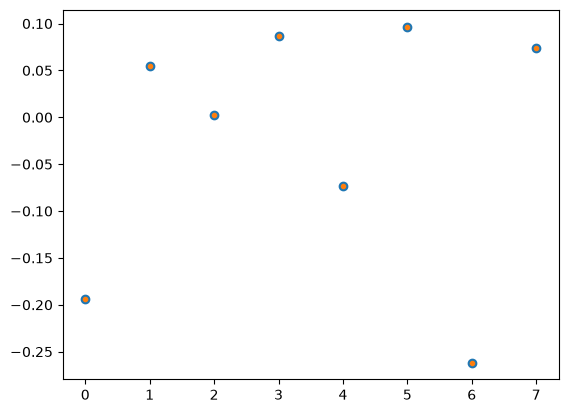

In [7]:
expected_sol = verify_by_plot(mat_raw_scr, rand_bvec, be_pauli.alpha, qsol)
assert np.linalg.norm(qsol - expected_sol) < 1e-10

### Banded Diagonals Block-Encoding

In [8]:
offsets = nonzero_diagonals(mat_raw_scr)
diags = extract_diagonals(mat_raw_scr, offsets)
be_banded = BlockEncoding.from_dense_diagonals(list(zip(diags, offsets)))
data_size = be_banded.data_size

rand_bvec = 1 - 2 * np.random.rand(2**data_size)
rand_bvec = (rand_bvec / np.linalg.norm(rand_bvec)).tolist()

qsol, qprog_banded_be = get_be_state(
    rand_bvec,
    lambda block, data: be_banded.unitary(data, block),
    be_banded.block_size,
    data_size,
)
show(qprog_banded_be)

Submitting state-vector job to simulator


Quantum program link: https://platform.classiq.io/circuit/3JgDgnZsRp8VY2l77B9wLhc8ZyJ


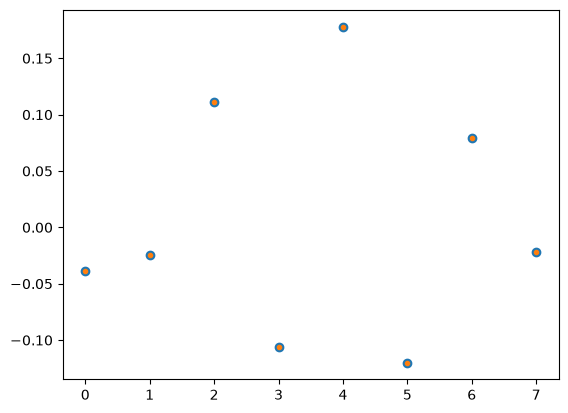

In [9]:
expected_sol = verify_by_plot(mat_raw_scr, rand_bvec, be_banded.alpha, qsol)
assert np.linalg.norm(qsol - expected_sol) < 1e-10